In [3]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Set up the environment
DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), 'data/raw/CMAPSS')
print(f"Data directory set to: {DATA_DIR}")

Data directory set to: /home/avinash/MTP/counterfactuals/data/CMAPSS


2. Loading the Data
Explanation: The CMAPSS dataset usually comes in four subsets (FD001 to FD004).

FD001: Single operating condition, one fault mode.

FD002: Six operating conditions, one fault mode.

FD003: Single operating condition, two fault modes.

FD004: Six operating conditions, two fault modes.

We will focus on FD001 for this analysis as it is the standard starting point, but the code applies to others with minor adjustments. We define the column names manually because the raw text files do not contain headers.

In [17]:
def read_cmapss_data(file_path):
    """
    Reads CMAPSS data from a given file path and returns a pandas DataFrame.
    """
    column_names = [
        'engine_id', 'cycle', 
        'setting_1', 'setting_2', 'setting_3'
    ] + [f'sensor_{i}' for i in range(1, 22)]
    
    data = pd.read_csv(file_path, sep='\s+', header=None, names=column_names)
    return data

# Example usage
cmapss_train_file = os.path.join(DATA_DIR, 'train_FD001.txt')
cmapss_data_train = read_cmapss_data(cmapss_train_file)

cmapss_test_file = os.path.join(DATA_DIR, 'test_FD001.txt')
cmapss_data_test = read_cmapss_data(cmapss_test_file)

#RUL
cmapss_rul_file = os.path.join(DATA_DIR, 'RUL_FD001.txt')
cmapss_rul = pd.read_csv(cmapss_rul_file, sep='\s+', header=None, names=['RUL'])    


<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_386190/1337697811.py:10: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_csv(file_path, sep='\s+', header=None, names=column_names)
/tmp/ipykernel_386190/1337697811.py:22: SyntaxWarning: invalid escape sequence '\s'
  cmapss_rul = pd.read_csv(cmapss_rul_file, sep='\s+', header=None, names=['RUL'])


In [21]:
cmapss_data_train.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [26]:
# Cell: Engine Lifecycle Analysis
print("="*80)
print("ENGINE LIFECYCLE ANALYSIS")
print("="*80)

# Calculate RUL (Remaining Useful Life) for each engine
def add_rul(df: pd.DataFrame, max_rul: int = 125) -> pd.DataFrame:
        """Add Remaining Useful Life (RUL) column"""
        df_rul = df.copy()
        # Calculate RUL for each unit
        max_cycles = df_rul.groupby('engine_id')['cycle'].max()
        df_rul = df_rul.merge(max_cycles.to_frame(name='max_cycle'), 
                               left_on='engine_id', right_index=True)
        df_rul['RUL'] = df_rul['max_cycle'] - df_rul['cycle']
        df_rul = df_rul.drop('max_cycle', axis=1)
        
        # Apply piecewise linear RUL (common in literature)
        df_rul['RUL'] = df_rul['RUL'].clip(upper=max_rul)
        
        return df_rul

cmapss_data_train = add_rul(cmapss_data_train)

# Lifecycle statistics per engine
lifecycle_stats = cmapss_data_train.groupby('engine_id')['cycle'].agg(['min', 'max', 'count']).reset_index()
lifecycle_stats.columns = ['engine_id', 'start_cycle', 'end_cycle', 'total_cycles']

print("\nLifecycle Statistics:")
print(lifecycle_stats.describe())
print(f"\nAverage engine lifetime: {lifecycle_stats['total_cycles'].mean():.2f} cycles")
print(f"Std dev of engine lifetime: {lifecycle_stats['total_cycles'].std():.2f} cycles")

ENGINE LIFECYCLE ANALYSIS

Lifecycle Statistics:
        engine_id  start_cycle   end_cycle  total_cycles
count  100.000000        100.0  100.000000    100.000000
mean    50.500000          1.0  206.310000    206.310000
std     29.011492          0.0   46.342749     46.342749
min      1.000000          1.0  128.000000    128.000000
25%     25.750000          1.0  177.000000    177.000000
50%     50.500000          1.0  199.000000    199.000000
75%     75.250000          1.0  229.250000    229.250000
max    100.000000          1.0  362.000000    362.000000

Average engine lifetime: 206.31 cycles
Std dev of engine lifetime: 46.34 cycles


In [27]:
cmapss_data_train.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,125


<Axes: title={'center': 'RUL over Cycles for Engine 1'}, xlabel='Cycle', ylabel='RUL'>

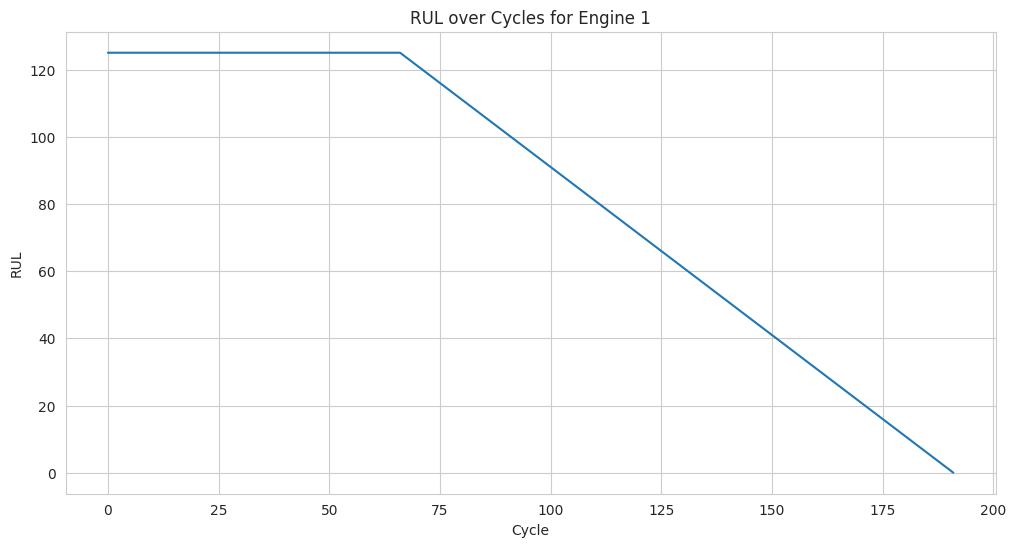

In [28]:
cmapss_data_train[cmapss_data_train["engine_id"]==1]['RUL'].plot(title="RUL over Cycles for Engine 1", xlabel="Cycle", ylabel="RUL")

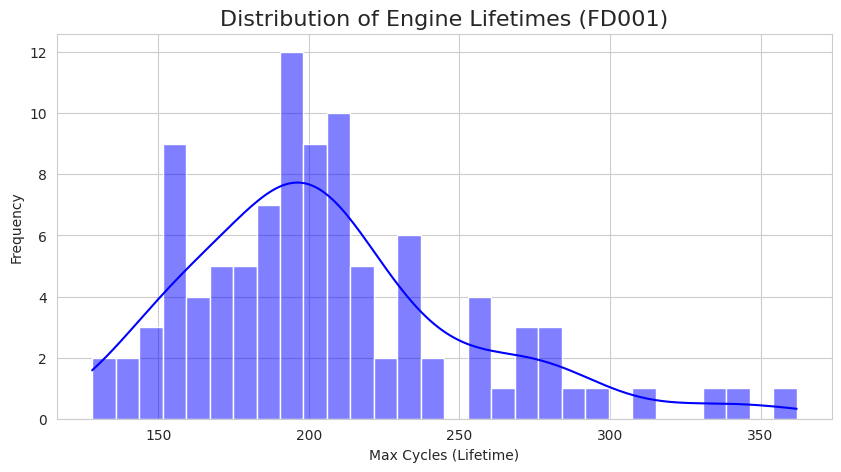

In [29]:
# Cell 4: Distribution of Engine Lifetimes (Max Cycles)

plt.figure(figsize=(10, 5))
sns.histplot(lifecycle_stats['total_cycles'], kde=True, bins=30, color='blue')
plt.title('Distribution of Engine Lifetimes (FD001)', fontsize=16)
plt.xlabel('Max Cycles (Lifetime)')
plt.ylabel('Frequency')
plt.show()

In [30]:
# Cell 5: Descriptive Statistics
cmapss_data_train.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
engine_id,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,1.776400e-15,14.6200,14.6200,14.6200,14.6200,14.6200


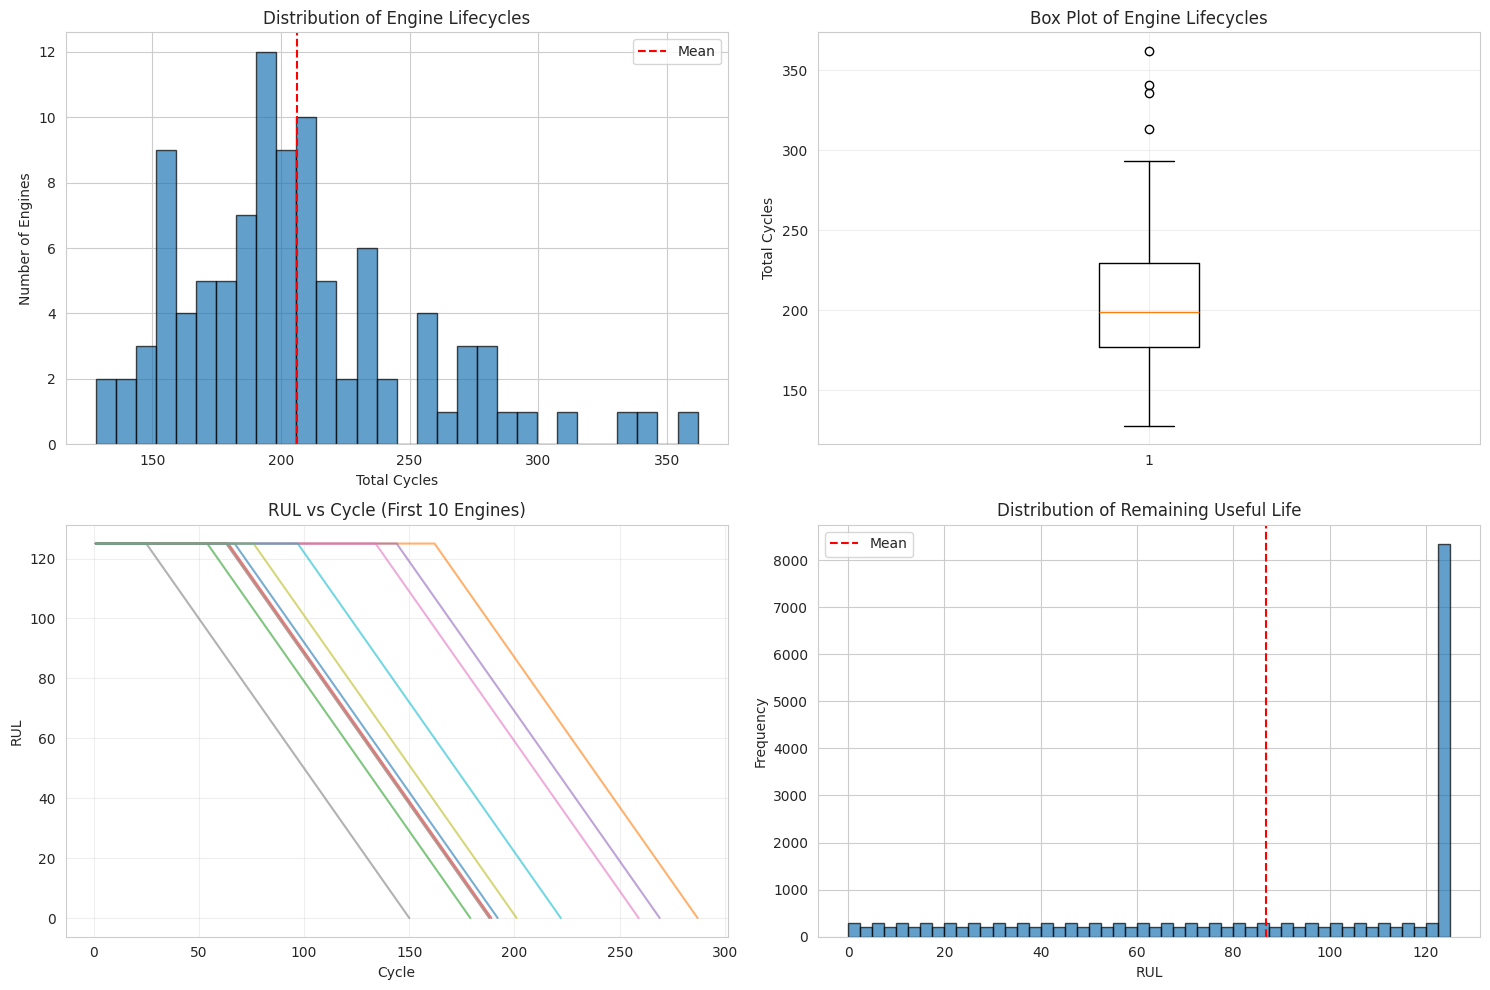

In [31]:
# Cell: Visualize Engine Lifecycles
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribution of engine lifecycles
axes[0, 0].hist(lifecycle_stats['total_cycles'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Total Cycles')
axes[0, 0].set_ylabel('Number of Engines')
axes[0, 0].set_title('Distribution of Engine Lifecycles')
axes[0, 0].axvline(lifecycle_stats['total_cycles'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 0].legend()

# Box plot of engine lifecycles
axes[0, 1].boxplot(lifecycle_stats['total_cycles'])
axes[0, 1].set_ylabel('Total Cycles')
axes[0, 1].set_title('Box Plot of Engine Lifecycles')
axes[0, 1].grid(True, alpha=0.3)

# Lifecycle trends for first 10 engines
for engine_id in range(1, min(11, cmapss_data_train['engine_id'].max() + 1)):
    engine_data = cmapss_data_train[cmapss_data_train['engine_id'] == engine_id]
    axes[1, 0].plot(engine_data['cycle'], engine_data['RUL'], alpha=0.6, label=f'Engine {engine_id}')
axes[1, 0].set_xlabel('Cycle')
axes[1, 0].set_ylabel('RUL')
axes[1, 0].set_title('RUL vs Cycle (First 10 Engines)')
axes[1, 0].grid(True, alpha=0.3)

# RUL distribution
axes[1, 1].hist(cmapss_data_train['RUL'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('RUL')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Remaining Useful Life')
axes[1, 1].axvline(cmapss_data_train['RUL'].mean(), color='red', linestyle='--', label='Mean')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

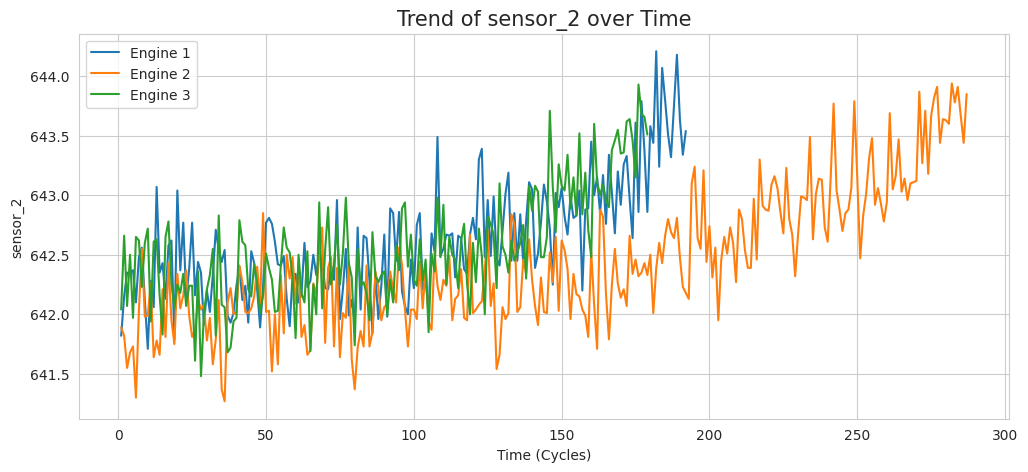

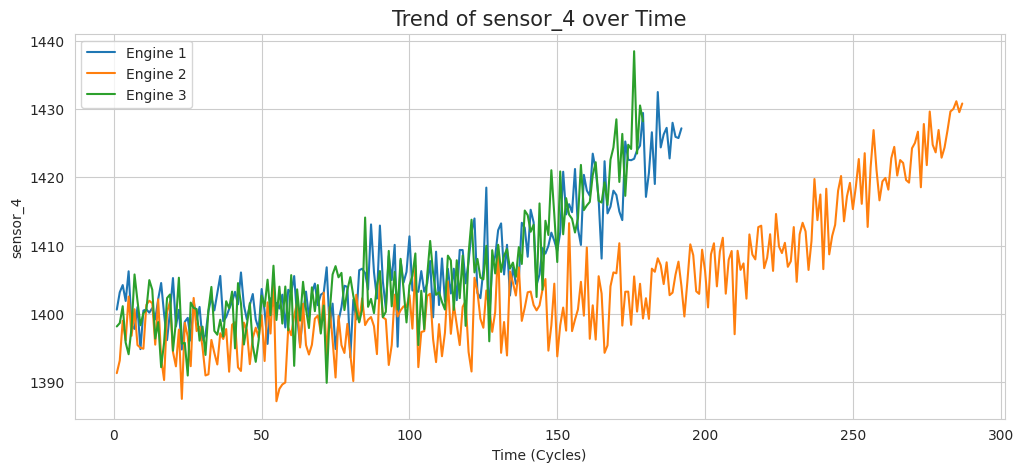

In [33]:
def plot_sensor_trends(units, sensor_name):
    plt.figure(figsize=(12, 5))
    for unit in units:
        subset = cmapss_data_train[cmapss_data_train['engine_id'] == unit]
        plt.plot(subset['cycle'], subset[sensor_name], label=f'Engine {unit}')
    
    plt.title(f'Trend of {sensor_name} over Time', fontsize=15)
    plt.xlabel('Time (Cycles)')
    plt.ylabel(sensor_name)
    plt.legend()
    plt.show()

# Visualize Sensor 2 (Total Temperature) and Sensor 4 (Total Pressure) for Units 1, 2, and 3
plot_sensor_trends([1, 2, 3], 'sensor_2')
plot_sensor_trends([1, 2, 3], 'sensor_4')

In [34]:
# Cell: Operating Settings Analysis
print("="*80)
print("OPERATING SETTINGS ANALYSIS")
print("="*80)

settings_cols = ['setting_1', 'setting_2', 'setting_3']
print("\nOperating Settings Statistics:")
print(cmapss_data[settings_cols].describe())

# Check unique values
print("\nUnique Values per Setting:")
for col in settings_cols:
    print(f"{col}: {cmapss_data[col].nunique()} unique values")
    print(f"  Range: [{cmapss_data[col].min():.4f}, {cmapss_data[col].max():.4f}]")

OPERATING SETTINGS ANALYSIS

Operating Settings Statistics:
          setting_1     setting_2  setting_3
count  20631.000000  20631.000000    20631.0
mean      -0.000009      0.000002      100.0
std        0.002187      0.000293        0.0
min       -0.008700     -0.000600      100.0
25%       -0.001500     -0.000200      100.0
50%        0.000000      0.000000      100.0
75%        0.001500      0.000300      100.0
max        0.008700      0.000600      100.0

Unique Values per Setting:
setting_1: 158 unique values
  Range: [-0.0087, 0.0087]
setting_2: 13 unique values
  Range: [-0.0006, 0.0006]
setting_3: 1 unique values
  Range: [100.0000, 100.0000]


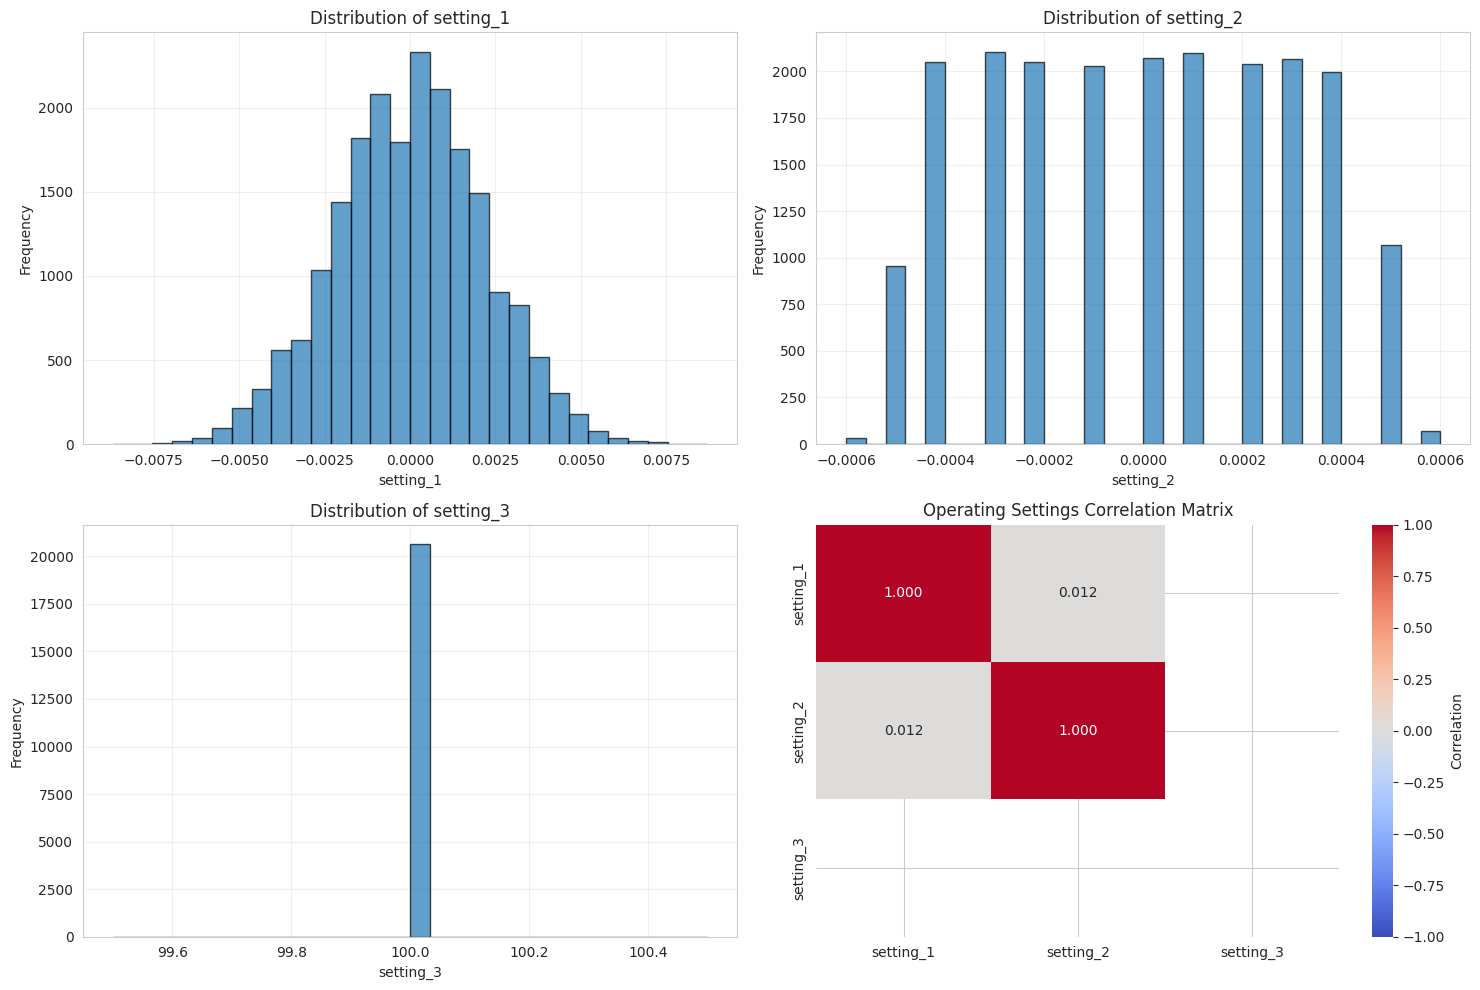

In [36]:
# Cell: Visualize Operating Settings
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Settings distributions
for idx, setting in enumerate(settings_cols):
    row = idx // 2
    col = idx % 2
    axes[row, col].hist(cmapss_data_train[setting], bins=30, edgecolor='black', alpha=0.7)
    axes[row, col].set_xlabel(setting)
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].set_title(f'Distribution of {setting}')
    axes[row, col].grid(True, alpha=0.3)

# Settings correlation heatmap
axes[1, 1].clear()
settings_corr = cmapss_data_train[settings_cols].corr()
sns.heatmap(settings_corr, annot=True, fmt='.3f', cmap='coolwarm', ax=axes[1, 1], 
            cbar_kws={'label': 'Correlation'}, vmin=-1, vmax=1)
axes[1, 1].set_title('Operating Settings Correlation Matrix')

plt.tight_layout()
plt.show()

In [37]:
# Cell: Sensor Data Analysis
print("="*80)
print("SENSOR DATA ANALYSIS")
print("="*80)

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
print("\nSensor Statistics:")
print(cmapss_data_train[sensor_cols].describe())

# Check for constant sensors
print("\nSensor Variability Analysis:")
sensor_variability = []
for sensor in sensor_cols:
    std = cmapss_data_train[sensor].std()
    unique_vals = cmapss_data_train[sensor].nunique()
    sensor_variability.append({
        'Sensor': sensor,
        'Std Dev': std,
        'Unique Values': unique_vals,
        'Min': cmapss_data_train[sensor].min(),
        'Max': cmapss_data_train[sensor].max(),
        'Is_Constant': std < 1e-5
    })

variability_df = pd.DataFrame(sensor_variability)
print(variability_df)

# Identify constant sensors
constant_sensors = variability_df[variability_df['Is_Constant']]['Sensor'].tolist()
print(f"\nConstant/Low-variance Sensors: {constant_sensors}")

# Identify useful sensors
useful_sensors = variability_df[~variability_df['Is_Constant']]['Sensor'].tolist()
print(f"\nUseful Sensors ({len(useful_sensors)}): {useful_sensors}")

SENSOR DATA ANALYSIS

Sensor Statistics:
       sensor_1      sensor_2      sensor_3      sensor_4      sensor_5  \
count  20631.00  20631.000000  20631.000000  20631.000000  2.063100e+04   
mean     518.67    642.680934   1590.523119   1408.933782  1.462000e+01   
std        0.00      0.500053      6.131150      9.000605  1.776400e-15   
min      518.67    641.210000   1571.040000   1382.250000  1.462000e+01   
25%      518.67    642.325000   1586.260000   1402.360000  1.462000e+01   
50%      518.67    642.640000   1590.100000   1408.040000  1.462000e+01   
75%      518.67    643.000000   1594.380000   1414.555000  1.462000e+01   
max      518.67    644.530000   1616.910000   1441.490000  1.462000e+01   

           sensor_6      sensor_7      sensor_8      sensor_9  sensor_10  ...  \
count  20631.000000  20631.000000  20631.000000  20631.000000    20631.0  ...   
mean      21.609803    553.367711   2388.096652   9065.242941        1.3  ...   
std        0.001389      0.885092      0

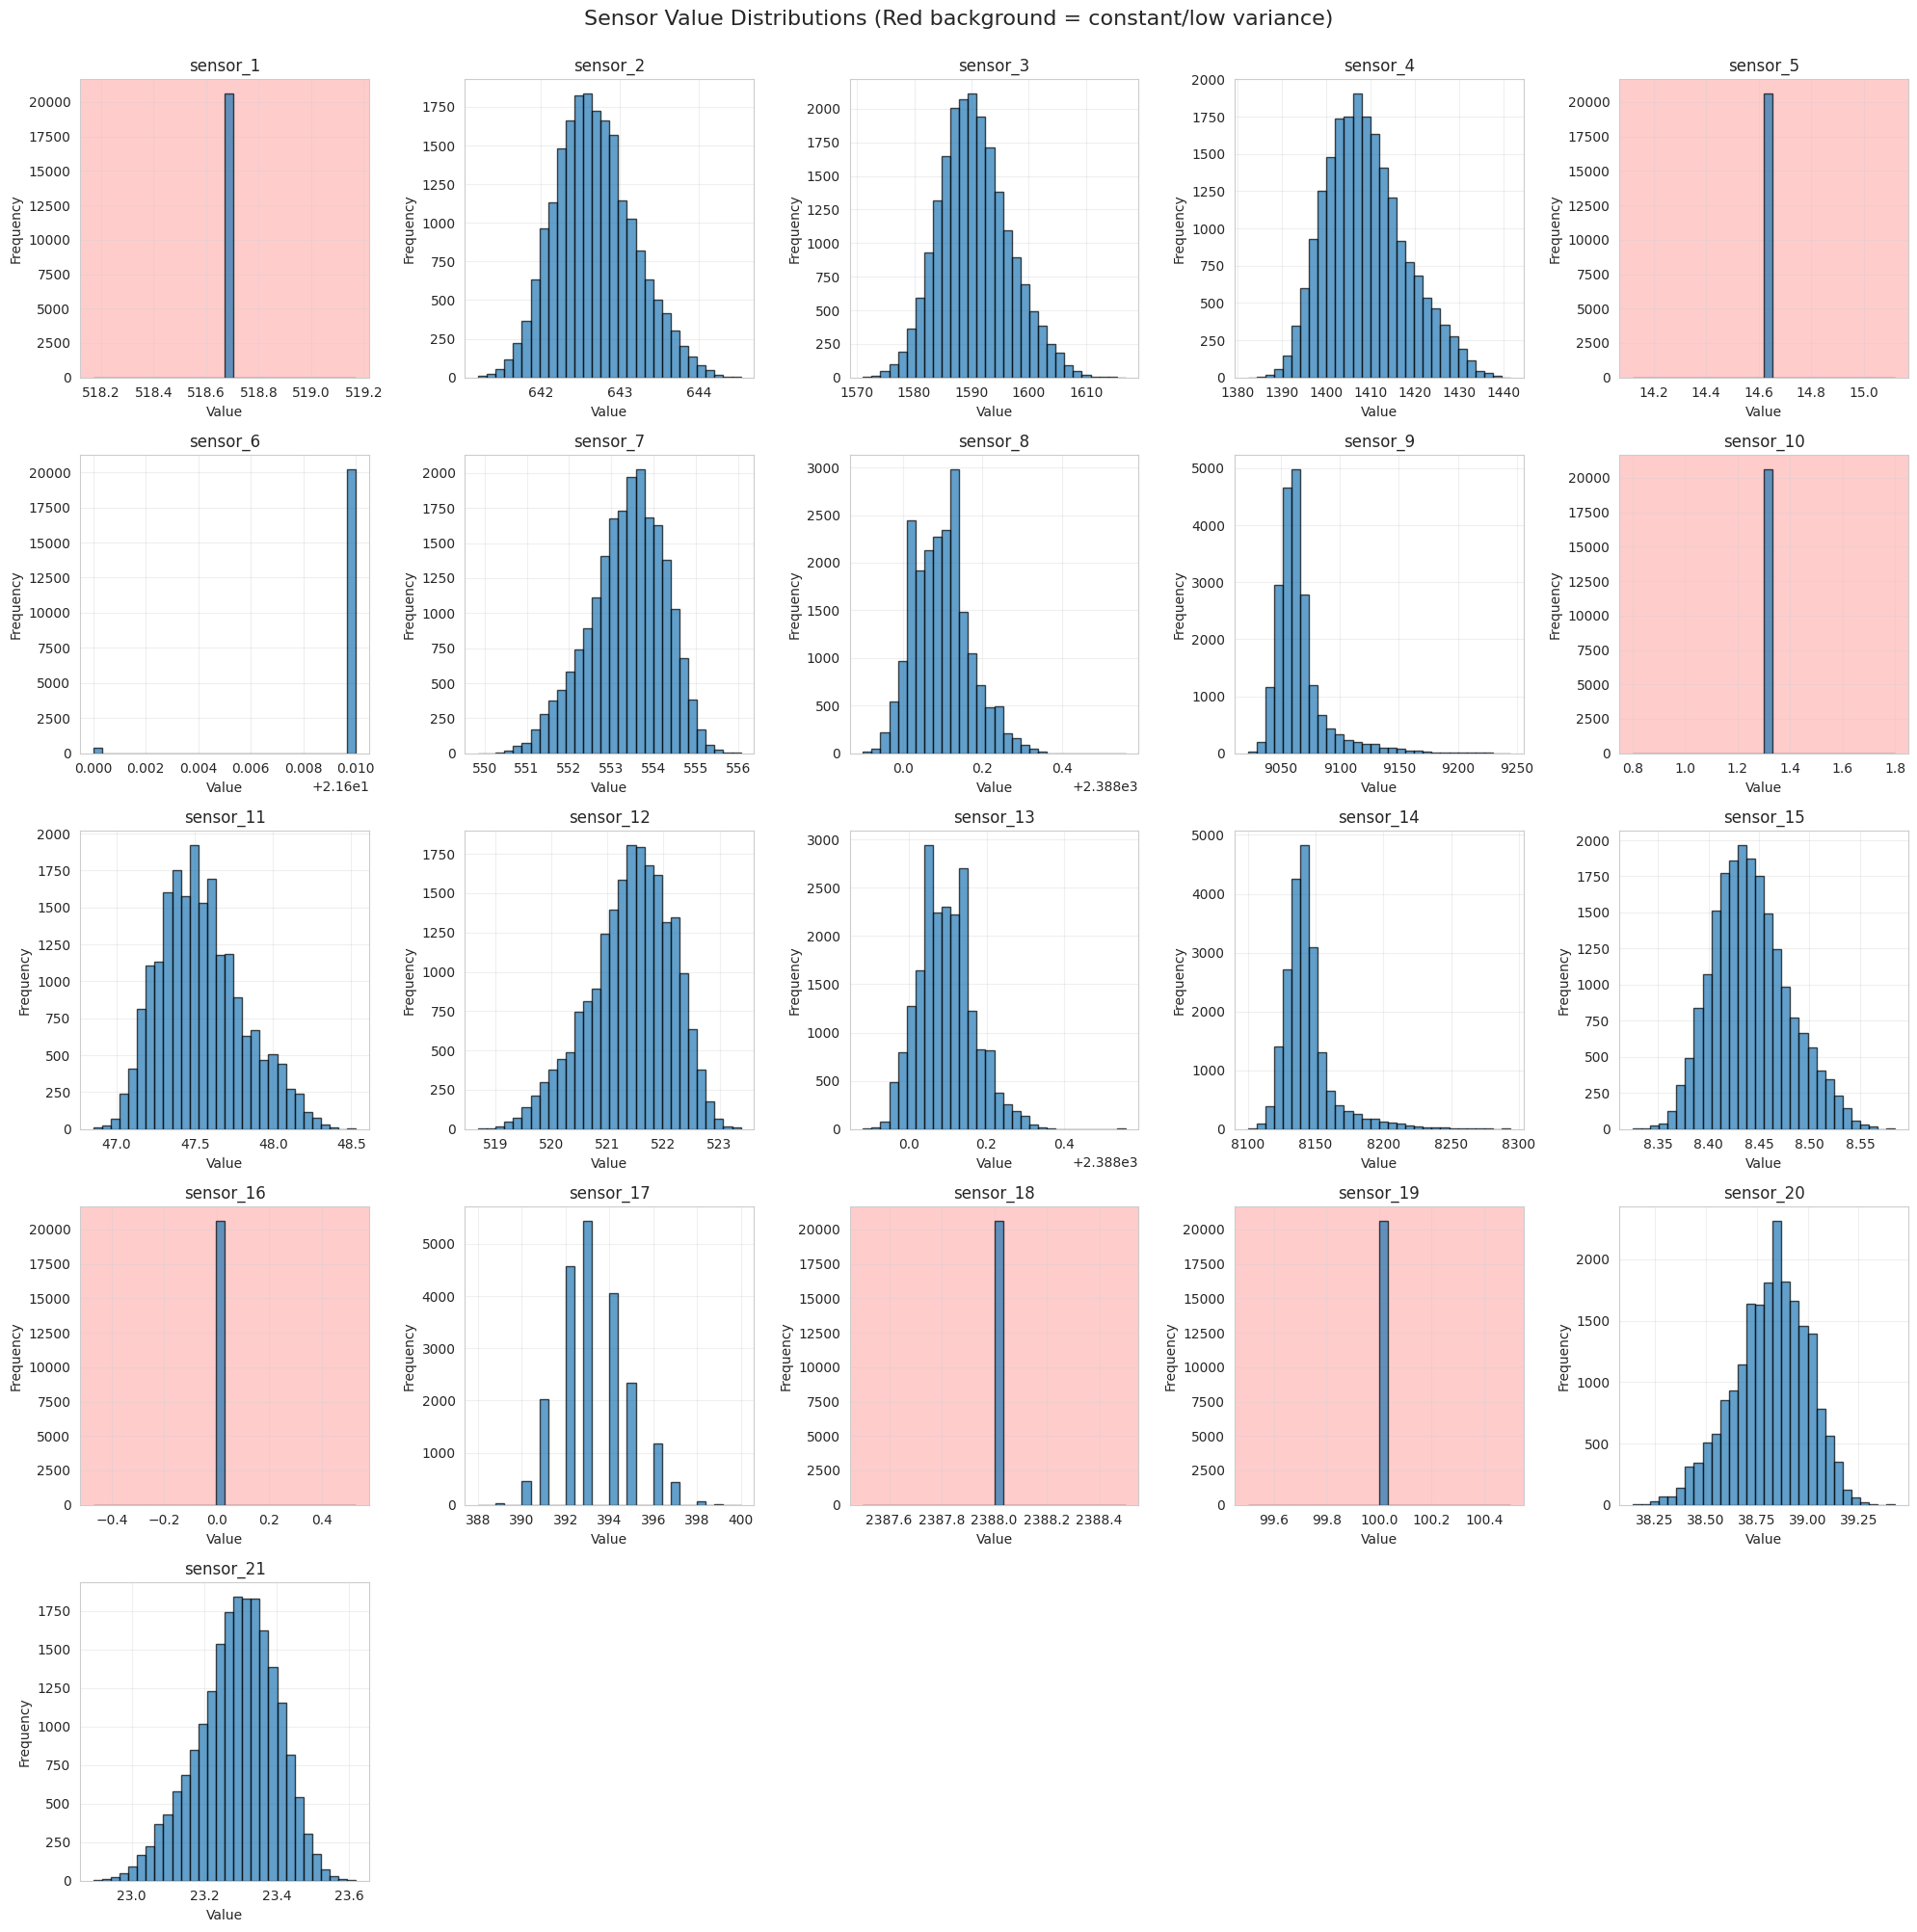

In [38]:
# Cell: Visualize Sensor Distributions
n_sensors = len(sensor_cols)
n_cols = 5
n_rows = (n_sensors + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for idx, sensor in enumerate(sensor_cols):
    axes[idx].hist(cmapss_data_train[sensor], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(sensor)
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)
    
    # Highlight if constant
    if sensor in constant_sensors:
        axes[idx].set_facecolor('#ffcccc')

# Hide unused subplots
for idx in range(len(sensor_cols), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Sensor Value Distributions (Red background = constant/low variance)', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

In [41]:
# Cell: Sensor Correlation Analysis
print("="*80)
print("SENSOR CORRELATION ANALYSIS")
print("="*80)

# Calculate correlation matrix for useful sensors only
if useful_sensors:
    sensor_corr = cmapss_data_train[useful_sensors].corr()
    
    # Find highly correlated sensor pairs
    high_corr_pairs = []
    for i in range(len(sensor_corr.columns)):
        for j in range(i+1, len(sensor_corr.columns)):
            corr_val = sensor_corr.iloc[i, j]
            if abs(corr_val) > 0.8:
                high_corr_pairs.append({
                    'Sensor 1': sensor_corr.columns[i],
                    'Sensor 2': sensor_corr.columns[j],
                    'Correlation': corr_val
                })
    
    if high_corr_pairs:
        print("\nHighly Correlated Sensor Pairs (|r| > 0.8):")
        print(pd.DataFrame(high_corr_pairs))
    else:
        print("\nNo highly correlated sensor pairs found (|r| > 0.8)")

SENSOR CORRELATION ANALYSIS

Highly Correlated Sensor Pairs (|r| > 0.8):
    Sensor 1   Sensor 2  Correlation
0   sensor_4  sensor_11     0.830136
1   sensor_4  sensor_12    -0.815591
2   sensor_7  sensor_11    -0.822805
3   sensor_7  sensor_12     0.812713
4   sensor_8  sensor_13     0.826084
5   sensor_9  sensor_14     0.963157
6  sensor_11  sensor_12    -0.846884


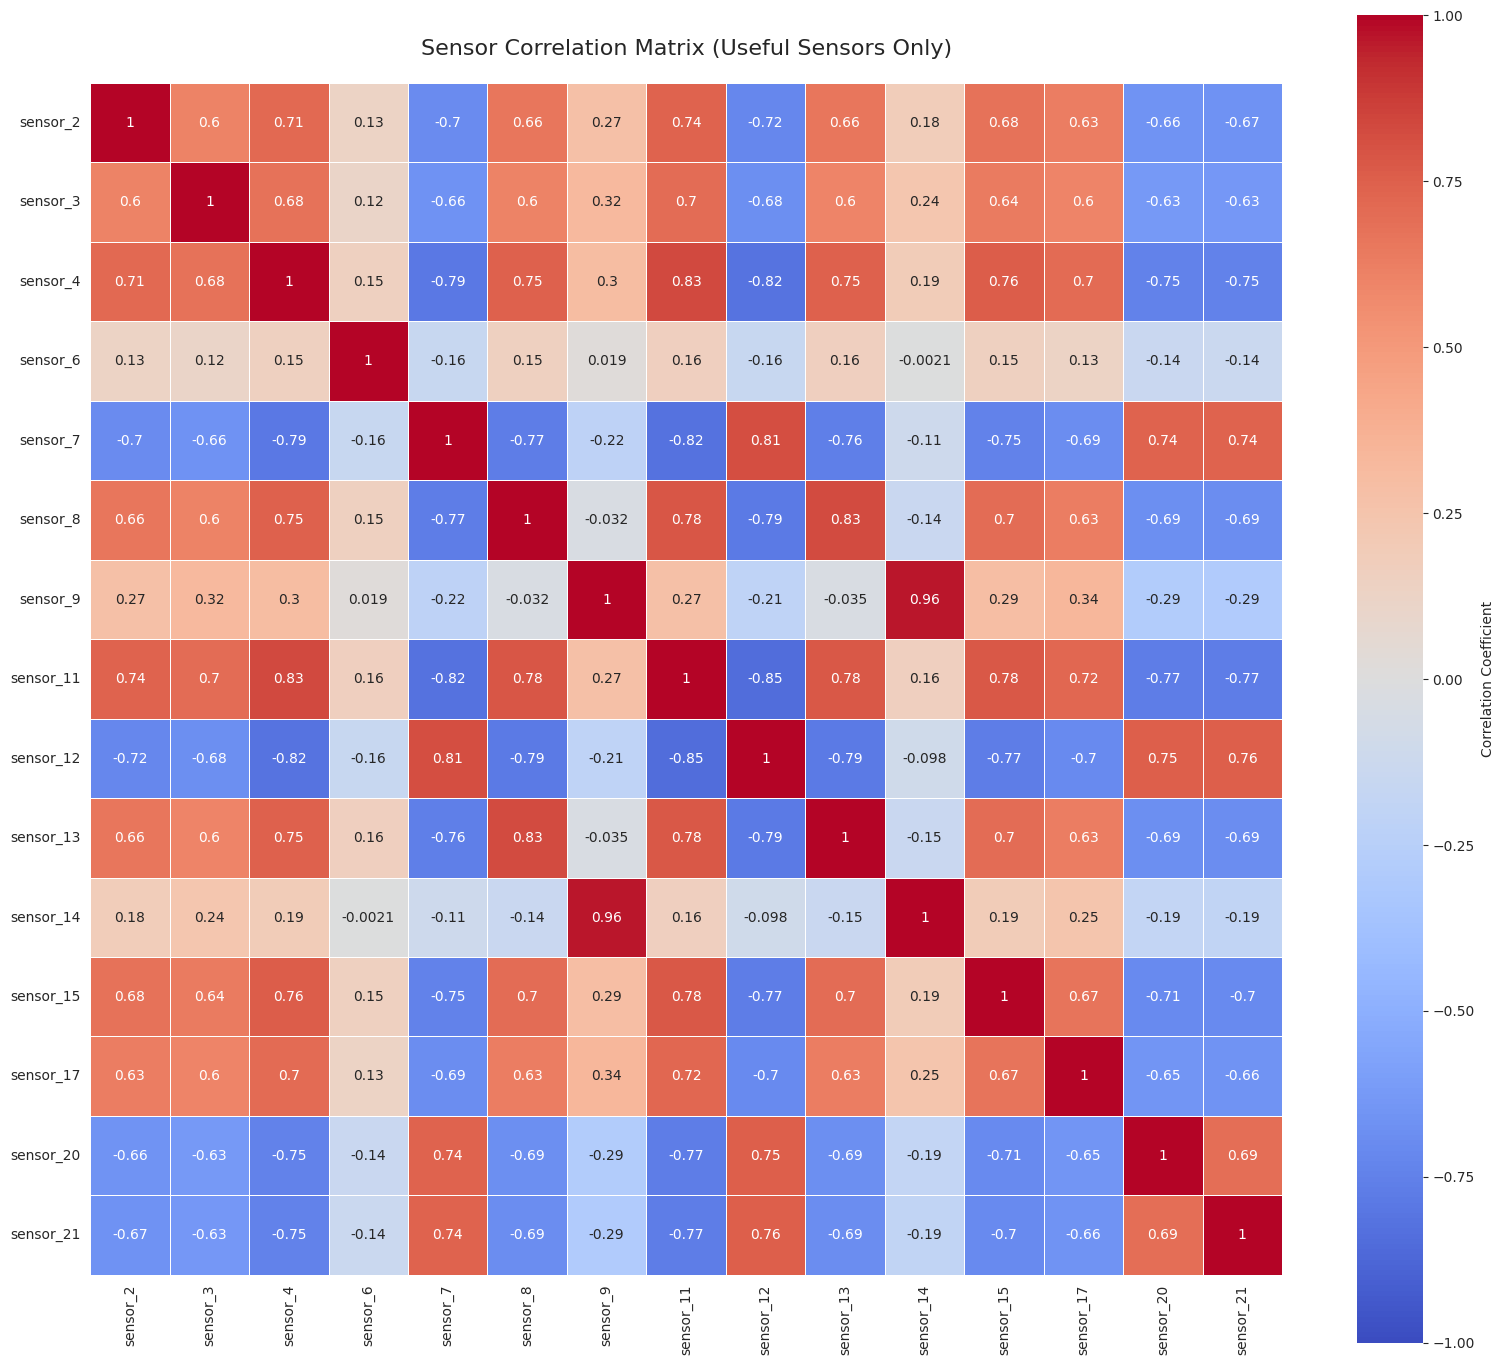

In [42]:
# Cell: Visualize Sensor Correlation Matrix
if useful_sensors:
    plt.figure(figsize=(16, 14))
    sns.heatmap(sensor_corr, annot=True, cmap='coolwarm', center=0,
                vmin=-1, vmax=1, square=True, linewidths=0.5,
                cbar_kws={'label': 'Correlation Coefficient'})
    plt.title('Sensor Correlation Matrix (Useful Sensors Only)', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

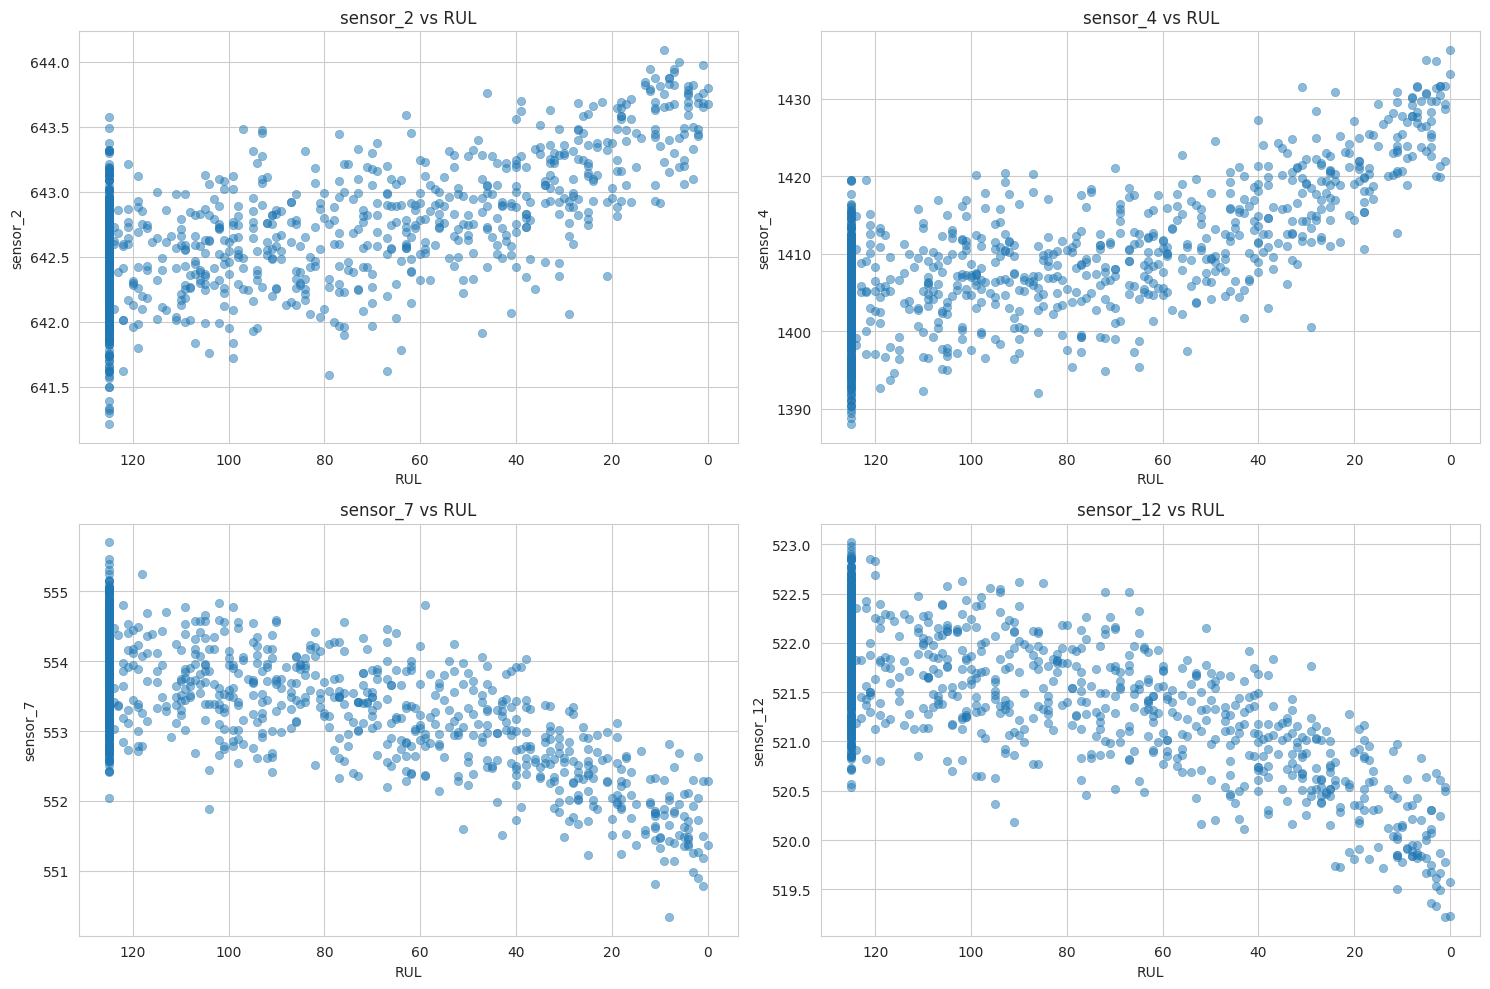

In [44]:
# Cell 9: Scatter Plot of Most Correlated Sensors vs RUL

# Let's pick 4 highly correlated sensors (example: sensor_2, sensor_4, sensor_7, sensor_12)
# Note: Adjust sensor names based on the filtered data available
sensors_to_plot = ['sensor_2', 'sensor_4', 'sensor_7', 'sensor_12'] 

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, sensor in enumerate(sensors_to_plot):
    # Sample 5% of data points to avoid overplotting and slow rendering
    sample_data = cmapss_data_train[useful_sensors + ['RUL']].sample(frac=0.05, random_state=42)
    sns.scatterplot(data=sample_data, x='RUL', y=sensor, ax=axes[i], alpha=0.5, edgecolor=None)
    axes[i].set_title(f'{sensor} vs RUL')
    axes[i].invert_xaxis() # We invert X so 0 (Failure) is on the right, or keep standard RUL (0 on left)
    # Standard RUL view: High RUL (Healthy) -> Low RUL (Failure)

plt.tight_layout()
plt.show()

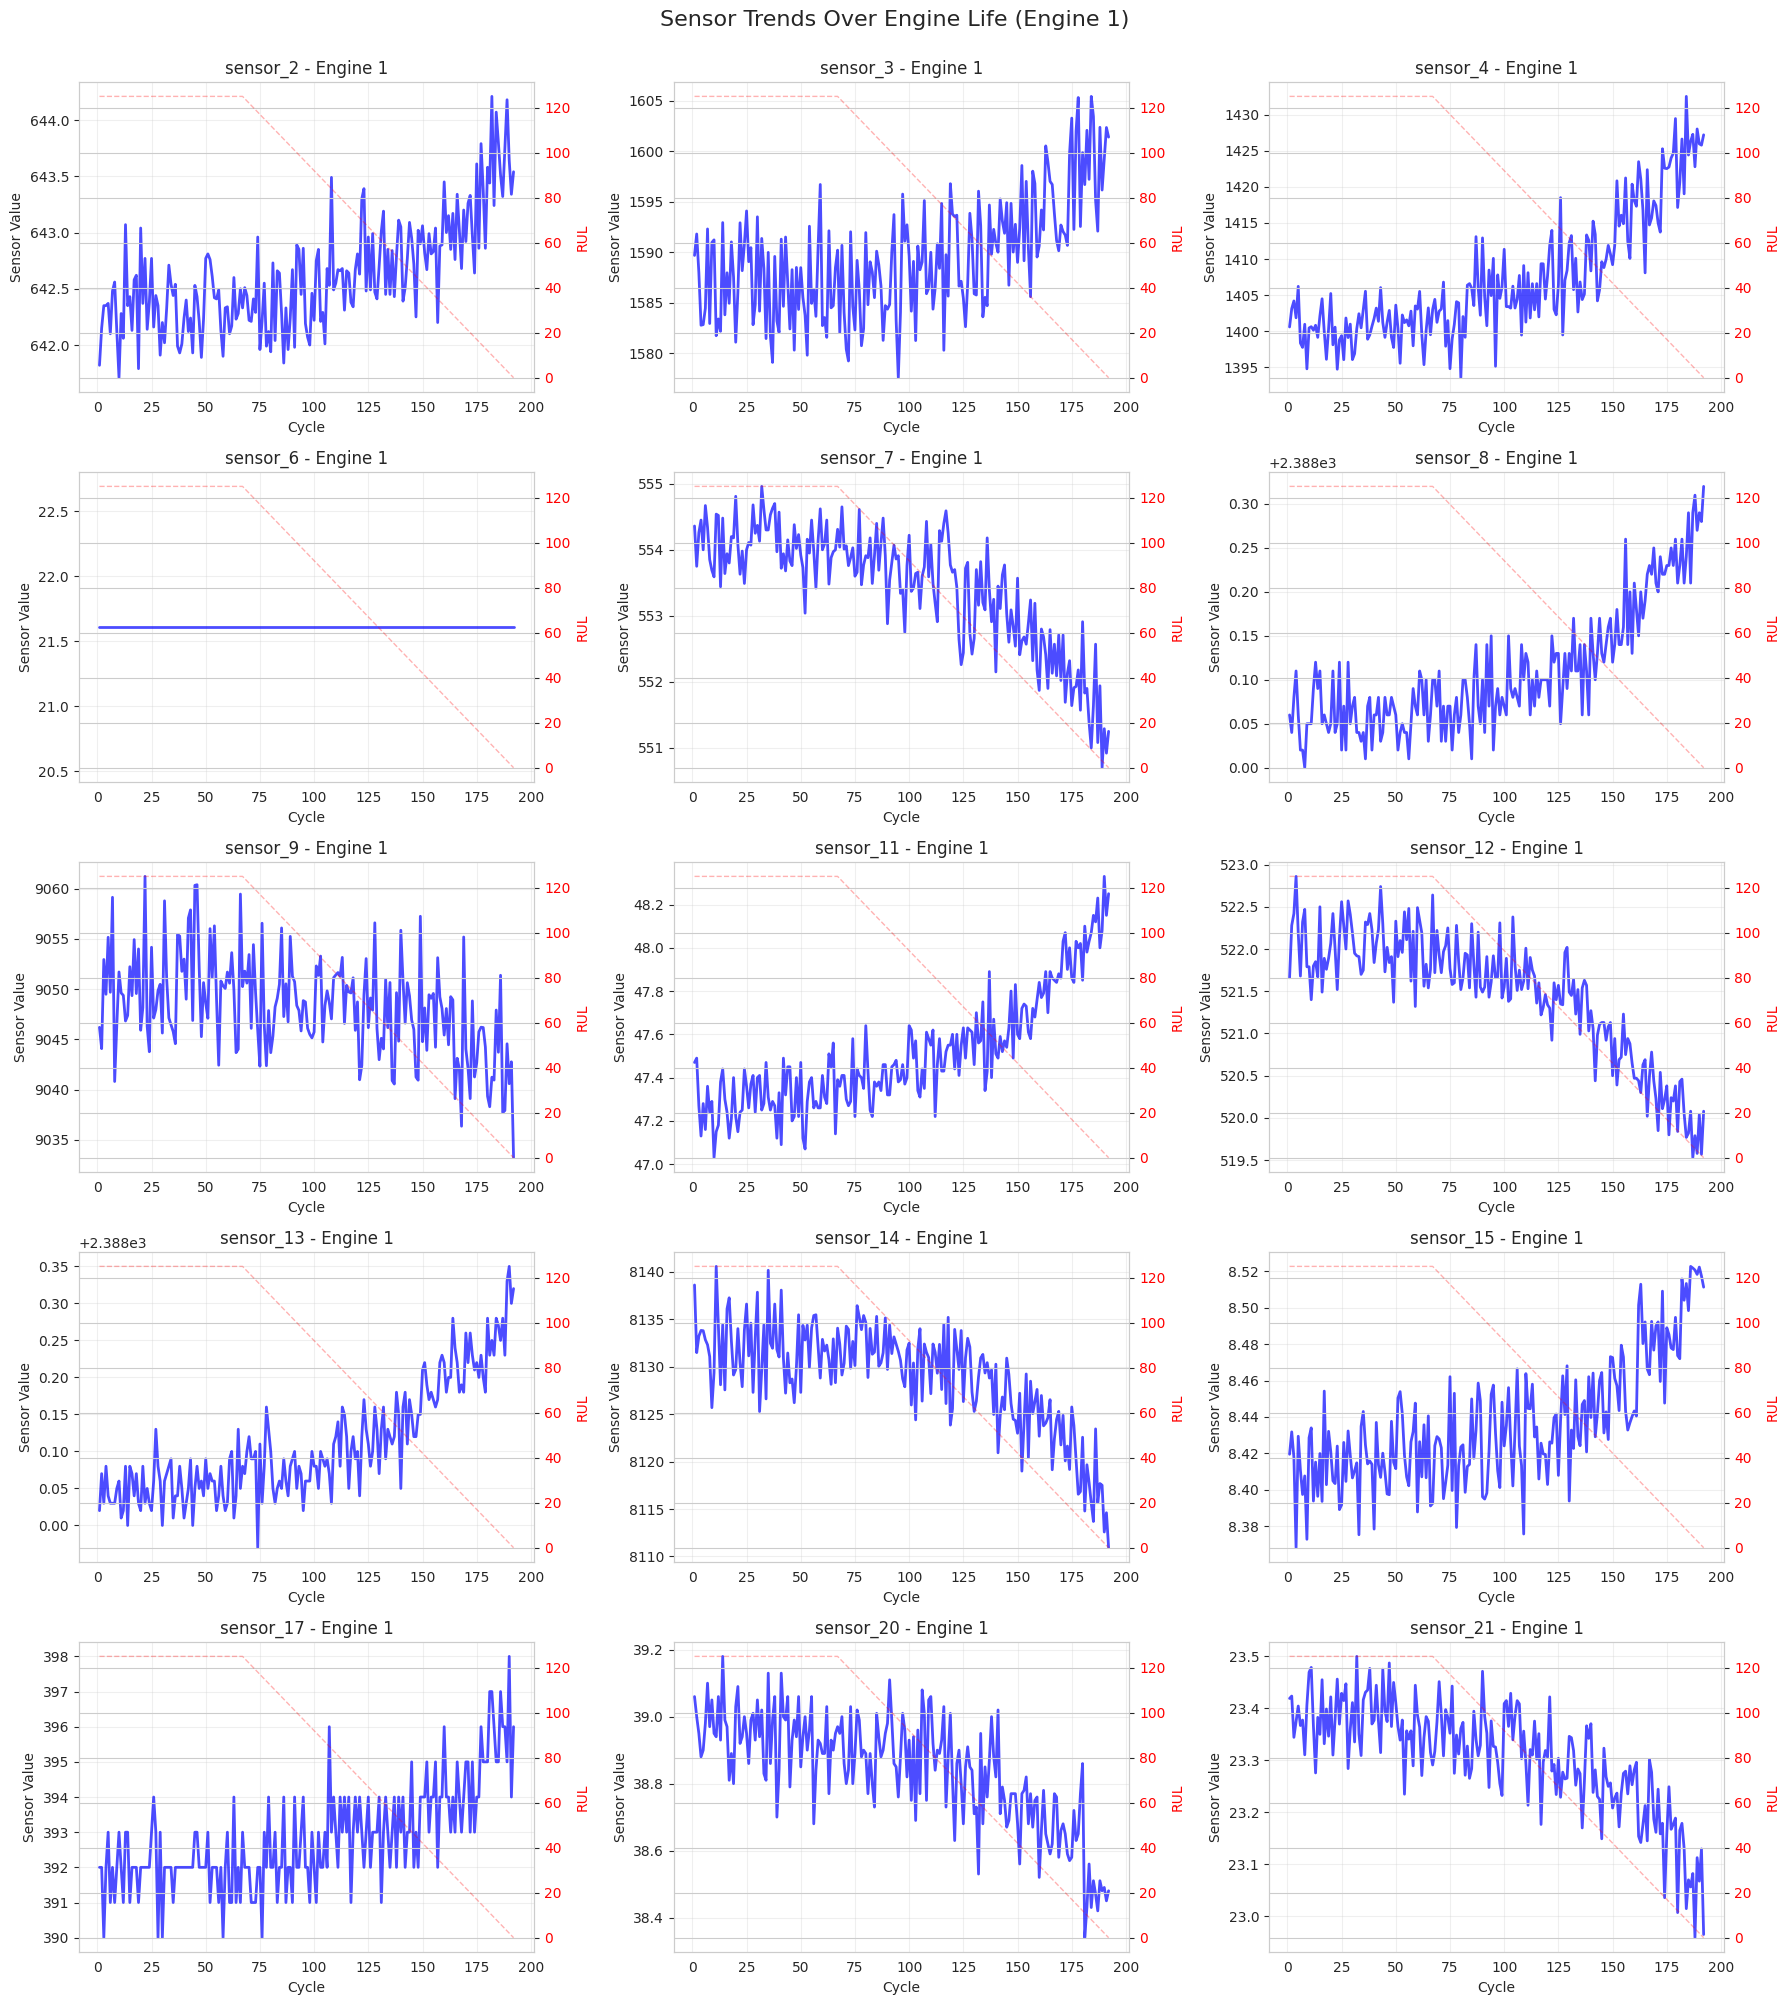

In [45]:
# Cell: Sensor Trends Over Engine Life
# Plot sensor trends for a sample engine
sample_engine_id = 1
sample_engine_data = cmapss_data_train[cmapss_data_train['engine_id'] == sample_engine_id]

if useful_sensors:
    n_sensors_plot = len(useful_sensors)
    n_cols = 3
    n_rows = (n_sensors_plot + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
    axes = axes.flatten()
    
    for idx, sensor in enumerate(useful_sensors):
        axes[idx].plot(sample_engine_data['cycle'], sample_engine_data[sensor], 
                      linewidth=2, color='blue', alpha=0.7)
        axes[idx].set_xlabel('Cycle')
        axes[idx].set_ylabel('Sensor Value')
        axes[idx].set_title(f'{sensor} - Engine {sample_engine_id}')
        axes[idx].grid(True, alpha=0.3)
        
        # Add RUL on secondary axis
        ax2 = axes[idx].twinx()
        ax2.plot(sample_engine_data['cycle'], sample_engine_data['RUL'], 
                color='red', alpha=0.3, linestyle='--', linewidth=1)
        ax2.set_ylabel('RUL', color='red')
        ax2.tick_params(axis='y', labelcolor='red')
    
    # Hide unused subplots
    for idx in range(len(useful_sensors), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'Sensor Trends Over Engine Life (Engine {sample_engine_id})', 
                 fontsize=16, y=1.00)
    plt.tight_layout()
    plt.show()

In [46]:
# Cell: Degradation Pattern Analysis
print("="*80)
print("DEGRADATION PATTERN ANALYSIS")
print("="*80)

# Analyze sensor behavior in early vs late life
early_life_threshold = 0.2  # First 20% of life
late_life_threshold = 0.8   # Last 20% of life

cmapss_data_train['life_percentage'] = cmapss_data_train['cycle'] / (cmapss_data_train['RUL'] + cmapss_data_train['cycle'])
cmapss_data_train['life_stage'] = pd.cut(cmapss_data_train['life_percentage'], 
                                     bins=[0, early_life_threshold, late_life_threshold, 1.0],
                                     labels=['Early', 'Middle', 'Late'])

print("\nData points per life stage:")
print(cmapss_data_train['life_stage'].value_counts())

# Compare sensor statistics across life stages
if useful_sensors:
    print("\nSensor Statistics by Life Stage:")
    for sensor in useful_sensors[:5]:  # Show first 5 useful sensors
        print(f"\n{sensor}:")
        print(cmapss_data_train.groupby('life_stage')[sensor].agg(['mean', 'std', 'min', 'max']))

DEGRADATION PATTERN ANALYSIS

Data points per life stage:
life_stage
Middle    13394
Late       4163
Early      3074
Name: count, dtype: int64

Sensor Statistics by Life Stage:

sensor_2:
                  mean       std     min     max
life_stage                                      
Early       642.382768  0.378252  641.25  643.71
Middle      642.561125  0.395770  641.21  644.12
Late        643.286572  0.388634  642.03  644.53

sensor_3:
                   mean       std      min      max
life_stage                                         
Early       1586.906415  4.641107  1571.06  1602.39
Middle      1589.103835  4.915926  1571.04  1606.69
Late        1597.760118  4.912177  1580.10  1616.91

sensor_4:
                   mean       std      min      max
life_stage                                         
Early       1402.789401  5.905681  1387.38  1422.97
Middle      1406.563086  6.611326  1382.25  1430.17
Late        1421.098307  6.415846  1400.51  1441.49

sensor_6:
              

/tmp/ipykernel_386190/1441798087.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(cmapss_data_train.groupby('life_stage')[sensor].agg(['mean', 'std', 'min', 'max']))
/tmp/ipykernel_386190/1441798087.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(cmapss_data_train.groupby('life_stage')[sensor].agg(['mean', 'std', 'min', 'max']))
/tmp/ipykernel_386190/1441798087.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence th

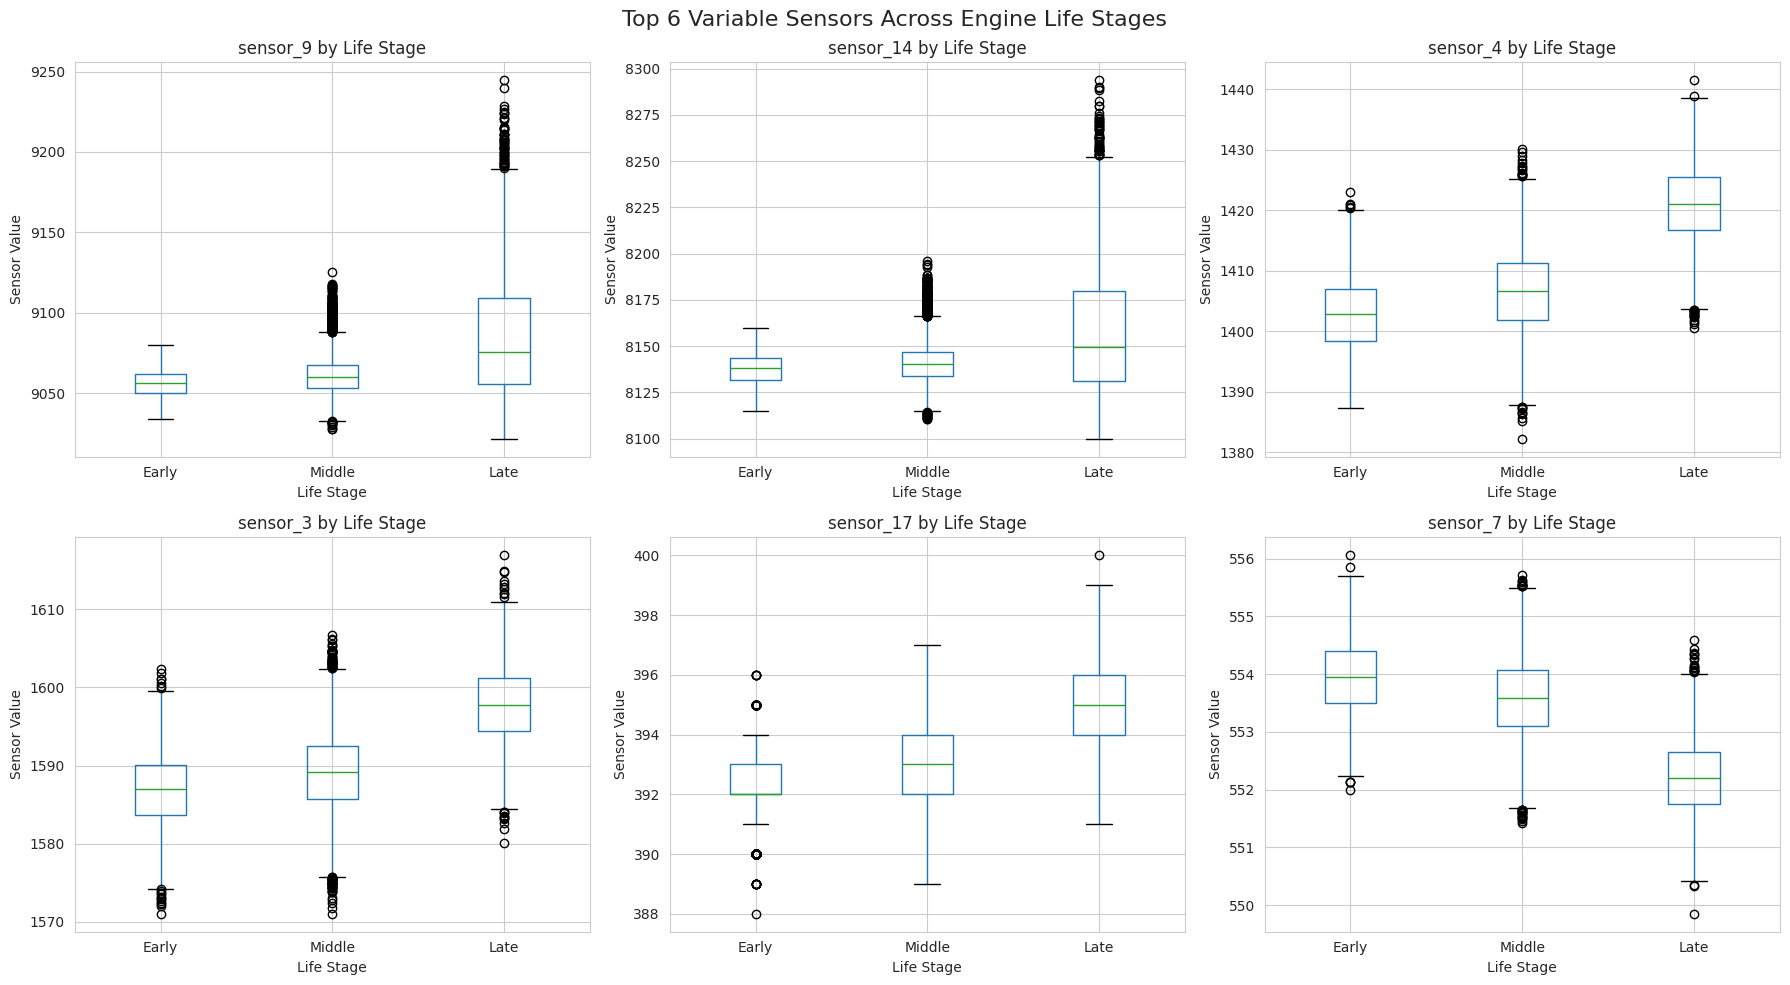

In [47]:
# Cell: Visualize Degradation Patterns
if useful_sensors:
    # Select top sensors with highest variation
    sensor_variations = {sensor: cmapss_data_train[sensor].std() for sensor in useful_sensors}
    top_sensors = sorted(sensor_variations.items(), key=lambda x: x[1], reverse=True)[:6]
    top_sensor_names = [s[0] for s in top_sensors]
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for idx, sensor in enumerate(top_sensor_names):
        # Box plot by life stage
        cmapss_data_train.boxplot(column=sensor, by='life_stage', ax=axes[idx])
        axes[idx].set_title(f'{sensor} by Life Stage')
        axes[idx].set_xlabel('Life Stage')
        axes[idx].set_ylabel('Sensor Value')
        axes[idx].get_figure().suptitle('')  # Remove automatic title
    
    plt.suptitle('Top 6 Variable Sensors Across Engine Life Stages', fontsize=16)
    plt.tight_layout()
    plt.show()

In [48]:
# Cell: Outlier Detection
print("="*80)
print("OUTLIER DETECTION")
print("="*80)

def detect_outliers_iqr(df, columns):
    """Detect outliers using IQR method"""
    outlier_info = []
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_info.append({
            'Column': col,
            'Outlier_Count': len(outliers),
            'Outlier_Percentage': (len(outliers) / len(df)) * 100,
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound
        })
    
    return pd.DataFrame(outlier_info)

if useful_sensors:
    outlier_df = detect_outliers_iqr(cmapss_data, useful_sensors)
    print("\nOutlier Analysis (IQR Method):")
    print(outlier_df.sort_values('Outlier_Percentage', ascending=False))

OUTLIER DETECTION

Outlier Analysis (IQR Method):
       Column  Outlier_Count  Outlier_Percentage  Lower_Bound  Upper_Bound
6    sensor_9           1686            8.172168   9028.62000   9093.90000
10  sensor_14           1543            7.479036   8110.64750   8170.90750
3    sensor_6            406            1.967912     21.61000     21.61000
5    sensor_8            320            1.551064   2387.91500   2388.27500
7   sensor_11            167            0.809461     46.82500     48.22500
1    sensor_3            165            0.799767   1574.08000   1606.56000
9   sensor_13            161            0.780379   2387.89000   2388.29000
8   sensor_12            146            0.707673    519.47500    523.43500
14  sensor_21            136            0.659202     23.00430     23.58430
0    sensor_2            128            0.620426    641.31250    644.01250
2    sensor_4            120            0.581649   1384.06750   1432.84750
11  sensor_15            120            0.581649  

['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


/tmp/ipykernel_386190/800574808.py:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(cmapss_data_train[sensor], label="Train", shade=True, color='blue')
/tmp/ipykernel_386190/800574808.py:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(cmapss_data_test[sensor], label="Test", shade=True, color='orange')
/tmp/ipykernel_386190/800574808.py:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(cmapss_data_train[sensor], label="Train", shade=True, color='blue')
/tmp/ipykernel_386190/800574808.py:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; 

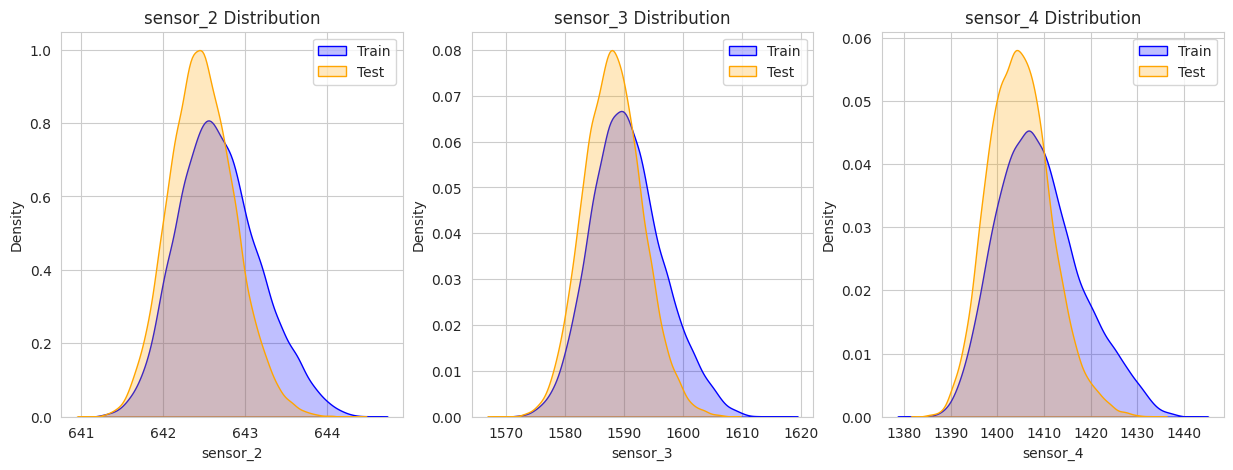

In [53]:
# Cell 10: Compare Train vs Test Distributions

# Identify remaining sensor columns
sensor_cols = [col for col in cmapss_data_train[useful_sensors].columns if 'sensor_' in col]
print(sensor_cols)
# Plot distribution for the first 3 active sensors
plt.figure(figsize=(15, 5))
for i, sensor in enumerate(sensor_cols[:3]):
    plt.subplot(1, 3, i+1)
    sns.kdeplot(cmapss_data_train[sensor], label="Train", shade=True, color='blue')
    sns.kdeplot(cmapss_data_test[sensor], label="Test", shade=True, color='orange')
    plt.title(f'{sensor} Distribution')
    plt.legend()

#plt.tight_layout()
plt.show()